In [1]:
import os

os.chdir(r"D:\business_analytics_project1")

print(os.getcwd())

D:\business_analytics_project1


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Load supplier-level engineered dataset
supplier_master = pd.read_csv(
    "data/processed/supplier_master.csv"
)

print("Supplier Master Shape:", supplier_master.shape)
display(supplier_master.head())

Supplier Master Shape: (40, 19)


,supplier_id,total_orders,late_orders,late_delivery_rate,avg_delivery_delay,max_delivery_delay,avg_actual_lead_time,avg_expected_lead_time,avg_lead_time_variance,lead_time_std,quality_incidents,total_scrap_qty,quality_incident_rate,quality_incident_rate_pct,otif_orders,otif_rate,total_order_quantity,distinct_parts_supplied,critical_parts_supplied
0,SUP001,659,278,42.19,0.27,10,40.70,40.53,0.17,7.40,3,3,0.004552,0.46,343,52.05,7839,7,0
1,SUP002,763,548,71.82,2.25,12,64.90,62.56,2.34,10.91,10,14,0.013106,1.31,196,25.69,15601,6,0
2,SUP003,633,424,66.98,1.91,12,44.16,42.38,1.78,9.23,6,11,0.009479,0.95,178,28.12,9558,6,0
3,SUP004,662,288,43.50,0.26,8,35.48,35.16,0.32,6.82,6,6,0.009063,0.91,348,52.57,8703,6,0
4,SUP005,436,289,66.28,1.93,11,53.51,51.41,2.10,7.43,1,1,0.002294,0.23,123,28.21,4791,6,3


In [12]:
print("Available Features:")
print(supplier_master.columns.tolist())

Available Features:
['supplier_id', 'total_orders', 'late_orders', 'late_delivery_rate', 'avg_delivery_delay', 'max_delivery_delay', 'avg_actual_lead_time', 'avg_expected_lead_time', 'avg_lead_time_variance', 'lead_time_std', 'quality_incidents', 'total_scrap_qty', 'quality_incident_rate', 'quality_incident_rate_pct', 'otif_orders', 'otif_rate', 'total_order_quantity', 'distinct_parts_supplied', 'critical_parts_supplied']


In [13]:
# Critical part concentration

supplier_master["critical_part_share"] = (
    supplier_master["critical_parts_supplied"]
    / supplier_master["distinct_parts_supplied"]
)

supplier_master["critical_part_share"] = (
    supplier_master["critical_part_share"].fillna(0)
)

display(
    supplier_master[
        [
            "supplier_id",
            "distinct_parts_supplied",
            "critical_parts_supplied",
            "critical_part_share"
        ]
    ].sort_values(
        "critical_part_share",
        ascending=False
    ).head(10)
)

,supplier_id,distinct_parts_supplied,critical_parts_supplied,critical_part_share
14,SUP015,7,4,0.571429
4,SUP005,6,3,0.500000
22,SUP023,4,2,0.500000
35,SUP036,8,4,0.500000
38,SUP039,4,2,0.500000
11,SUP012,14,5,0.357143
20,SUP021,6,2,0.333333
7,SUP008,6,2,0.333333
33,SUP034,7,2,0.285714
18,SUP019,8,2,0.250000


In [14]:
# Average order quantity handled per supplied part

supplier_master["order_quantity_per_part"] = (
    supplier_master["total_order_quantity"]
    / supplier_master["distinct_parts_supplied"]
)

display(
    supplier_master[
        [
            "supplier_id",
            "total_order_quantity",
            "distinct_parts_supplied",
            "order_quantity_per_part"
        ]
    ].sort_values(
        "order_quantity_per_part",
        ascending=False
    ).head(10)
)

,supplier_id,total_order_quantity,distinct_parts_supplied,order_quantity_per_part
23,SUP024,16150,6,2691.666667
1,SUP002,15601,6,2600.166667
8,SUP009,11741,5,2348.200000
37,SUP038,18714,8,2339.250000
26,SUP027,23791,11,2162.818182
35,SUP036,15202,8,1900.250000
16,SUP017,21270,12,1772.500000
27,SUP028,13934,8,1741.750000
10,SUP011,8563,5,1712.600000
5,SUP006,16781,10,1678.100000


In [15]:
# Quality incidents per 1,000 orders

supplier_master["quality_incidents_per_1000_orders"] = (
    supplier_master["quality_incidents"]
    / supplier_master["total_orders"]
) * 1000

display(
    supplier_master[
        [
            "supplier_id",
            "total_orders",
            "quality_incidents",
            "quality_incident_rate_pct",
            "quality_incidents_per_1000_orders"
        ]
    ].sort_values(
        "quality_incidents_per_1000_orders",
        ascending=False
    ).head(10)
)

,supplier_id,total_orders,quality_incidents,quality_incident_rate_pct,quality_incidents_per_1000_orders
22,SUP023,280,7,2.50,25.000000
23,SUP024,821,16,1.95,19.488429
26,SUP027,1311,24,1.83,18.306636
17,SUP018,607,11,1.81,18.121911
39,SUP040,1215,22,1.81,18.106996
32,SUP033,631,11,1.74,17.432647
33,SUP034,578,10,1.73,17.301038
8,SUP009,649,11,1.69,16.949153
12,SUP013,1156,19,1.64,16.435986
5,SUP006,1096,18,1.64,16.423358


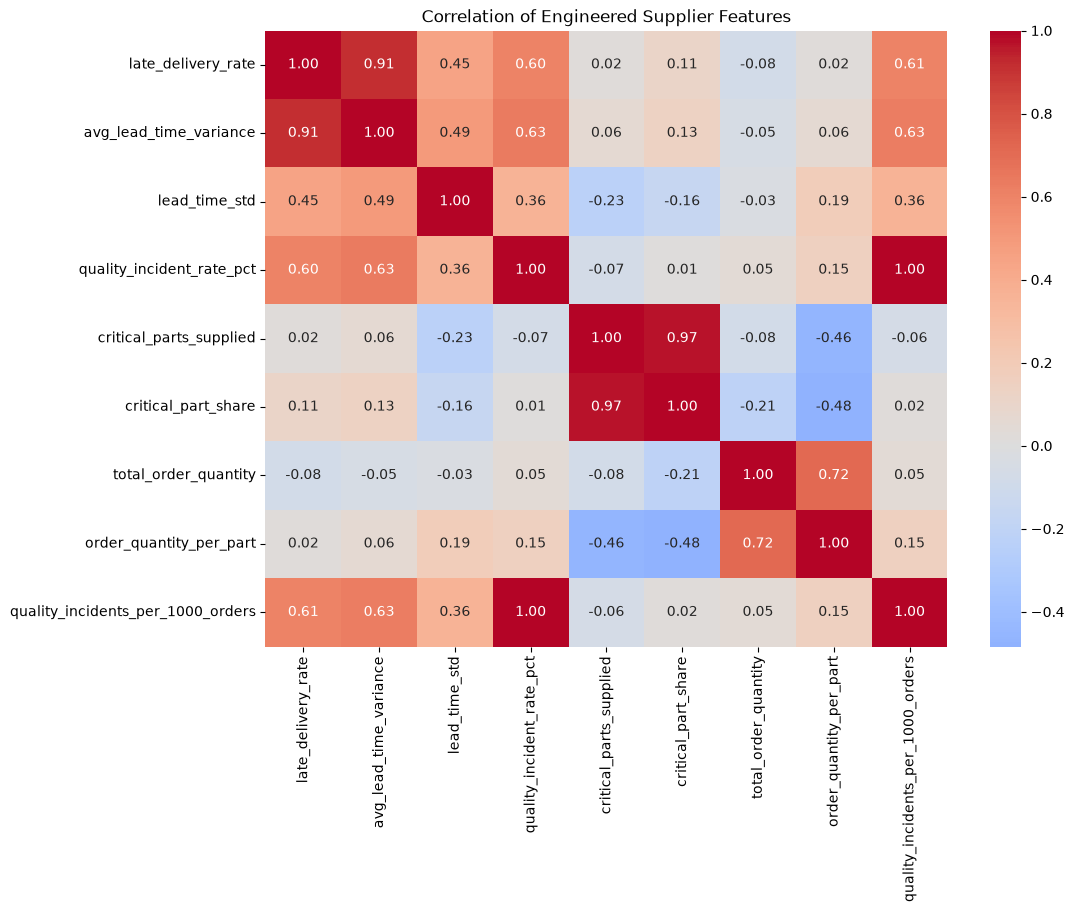

In [16]:
# Check correlations among existing and newly engineered features

feature_validation = supplier_master[
    [
        "late_delivery_rate",
        "avg_lead_time_variance",
        "lead_time_std",
        "quality_incident_rate_pct",
        "critical_parts_supplied",
        "critical_part_share",
        "total_order_quantity",
        "order_quantity_per_part",
        "quality_incidents_per_1000_orders"
    ]
].corr(method="spearman")

plt.figure(figsize=(11, 8))

sns.heatmap(
    feature_validation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation of Engineered Supplier Features")

plt.show()

In [17]:
# Delivery reliability

supplier_master["delivery_reliability"] = (
    100 - supplier_master["late_delivery_rate"]
)

display(
    supplier_master[
        [
            "supplier_id",
            "late_delivery_rate",
            "delivery_reliability",
            "otif_rate"
        ]
    ].sort_values(
        "delivery_reliability"
    ).head(10)
)

,supplier_id,late_delivery_rate,delivery_reliability,otif_rate
32,SUP033,96.35,3.65,3.01
22,SUP023,73.57,26.43,23.93
1,SUP002,71.82,28.18,25.69
25,SUP026,70.59,29.41,25.44
38,SUP039,70.26,29.74,25.16
14,SUP015,70.22,29.78,26.15
20,SUP021,70.17,29.83,26.00
8,SUP009,69.80,30.20,25.27
13,SUP014,69.16,30.84,27.05
24,SUP025,69.06,30.94,25.97


In [18]:
# Standardize lead-time related metrics

supplier_master["lead_time_variance_z"] = (
    supplier_master["avg_lead_time_variance"]
    - supplier_master["avg_lead_time_variance"].mean()
) / supplier_master["avg_lead_time_variance"].std()

supplier_master["lead_time_std_z"] = (
    supplier_master["lead_time_std"]
    - supplier_master["lead_time_std"].mean()
) / supplier_master["lead_time_std"].std()

display(
    supplier_master[
        [
            "supplier_id",
            "avg_lead_time_variance",
            "lead_time_std",
            "lead_time_variance_z",
            "lead_time_std_z"
        ]
    ].head(10)
)

,supplier_id,avg_lead_time_variance,lead_time_std,lead_time_variance_z,lead_time_std_z
0,SUP001,0.17,7.40,-0.876523,-0.096169
1,SUP002,2.34,10.91,0.859721,2.327923
2,SUP003,1.78,9.23,0.411658,1.167673
3,SUP004,0.32,6.82,-0.756506,-0.496732
4,SUP005,2.10,7.43,0.667694,-0.075451
5,SUP006,2.15,7.20,0.707699,-0.234294
6,SUP007,0.32,4.98,-0.756506,-1.767481
7,SUP008,0.31,8.87,-0.764507,0.919049
8,SUP009,2.11,10.17,0.675695,1.816860
9,SUP010,0.22,5.03,-0.836517,-1.732950


In [19]:
# Combined lead-time instability

supplier_master["lead_time_instability"] = (
    supplier_master["lead_time_variance_z"]
    + supplier_master["lead_time_std_z"]
) / 2

display(
    supplier_master[
        [
            "supplier_id",
            "lead_time_variance_z",
            "lead_time_std_z",
            "lead_time_instability"
        ]
    ].sort_values(
        "lead_time_instability",
        ascending=False
    ).head(10)
)

,supplier_id,lead_time_variance_z,lead_time_std_z,lead_time_instability
32,SUP033,4.164185,1.761611,2.962898
1,SUP002,0.859721,2.327923,1.593822
8,SUP009,0.675695,1.816860,1.246278
22,SUP023,0.795712,1.333423,1.064568
23,SUP024,0.795712,1.278173,1.036943
38,SUP039,0.867722,0.932861,0.900291
25,SUP026,0.579681,1.181486,0.880584
2,SUP003,0.411658,1.167673,0.789666
26,SUP027,0.555678,0.753299,0.654488
13,SUP014,0.611686,0.573736,0.592711


In [20]:
# Validate lead-time instability against supplier performance

lead_time_validation = supplier_master[
    [
        "lead_time_instability",
        "late_delivery_rate",
        "otif_rate",
        "quality_incident_rate_pct"
    ]
].corr(method="spearman")

display(lead_time_validation)

,lead_time_instability,late_delivery_rate,otif_rate,quality_incident_rate_pct
lead_time_instability,1.000000,0.812570,-0.811295,0.606709
late_delivery_rate,0.812570,1.000000,-0.985694,0.604645
otif_rate,-0.811295,-0.985694,1.000000,-0.604673
quality_incident_rate_pct,0.606709,0.604645,-0.604673,1.000000


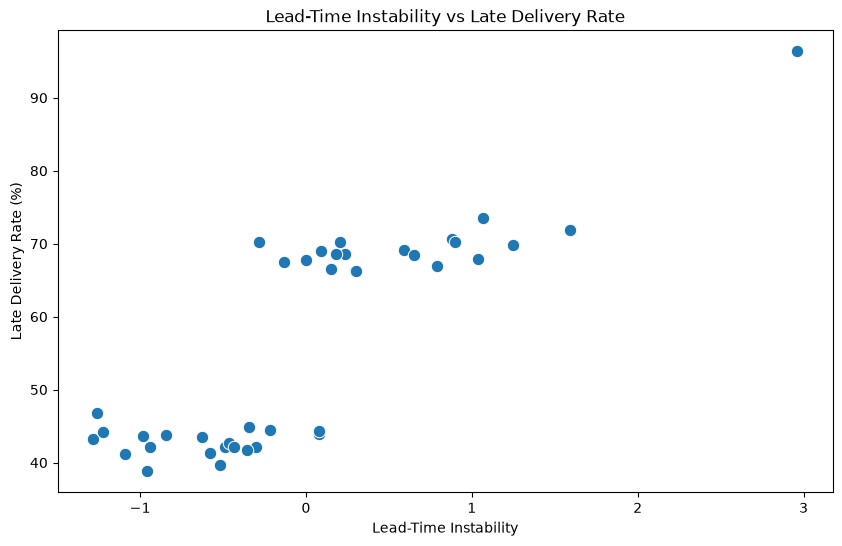

In [21]:
# Lead-time instability vs late delivery

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=supplier_master,
    x="lead_time_instability",
    y="late_delivery_rate",
    s=80
)

plt.title("Lead-Time Instability vs Late Delivery Rate")
plt.xlabel("Lead-Time Instability")
plt.ylabel("Late Delivery Rate (%)")

plt.show()

In [22]:
# Supplier share of total order quantity

total_order_quantity = supplier_master["total_order_quantity"].sum()

supplier_master["order_quantity_share"] = (
    supplier_master["total_order_quantity"]
    / total_order_quantity
) * 100

display(
    supplier_master[
        [
            "supplier_id",
            "total_order_quantity",
            "order_quantity_share"
        ]
    ].sort_values(
        "order_quantity_share",
        ascending=False
    ).head(10)
)

,supplier_id,total_order_quantity,order_quantity_share
26,SUP027,23791,5.472982
16,SUP017,21270,4.893041
37,SUP038,18714,4.305048
39,SUP040,16905,3.888898
5,SUP006,16781,3.860372
29,SUP030,16462,3.786988
23,SUP024,16150,3.715214
1,SUP002,15601,3.588920
35,SUP036,15202,3.497132
11,SUP012,14886,3.424439


In [23]:
# Standardize critical-part exposure measures

supplier_master["critical_parts_z"] = (
    supplier_master["critical_parts_supplied"]
    - supplier_master["critical_parts_supplied"].mean()
) / supplier_master["critical_parts_supplied"].std()

supplier_master["critical_share_z"] = (
    supplier_master["critical_part_share"]
    - supplier_master["critical_part_share"].mean()
) / supplier_master["critical_part_share"].std()

supplier_master["critical_exposure_index"] = (
    supplier_master["critical_parts_z"]
    + supplier_master["critical_share_z"]
) / 2

display(
    supplier_master[
        [
            "supplier_id",
            "critical_parts_supplied",
            "critical_part_share",
            "critical_exposure_index"
        ]
    ].sort_values(
        "critical_exposure_index",
        ascending=False
    ).head(10)
)

,supplier_id,critical_parts_supplied,critical_part_share,critical_exposure_index
14,SUP015,4,0.571429,2.235514
35,SUP036,4,0.500000,2.031904
11,SUP012,5,0.357143,2.002234
4,SUP005,3,0.500000,1.654354
22,SUP023,2,0.500000,1.276804
38,SUP039,2,0.500000,1.276804
29,SUP030,3,0.250000,0.941720
12,SUP013,3,0.230769,0.886902
7,SUP008,2,0.333333,0.801715
20,SUP021,2,0.333333,0.801715


In [24]:
# Final engineered feature set

engineered_features = [
    "supplier_id",
    "late_delivery_rate",
    "delivery_reliability",
    "avg_lead_time_variance",
    "lead_time_std",
    "lead_time_instability",
    "quality_incident_rate_pct",
    "quality_incidents_per_1000_orders",
    "critical_parts_supplied",
    "critical_part_share",
    "critical_exposure_index",
    "total_order_quantity",
    "order_quantity_share",
    "order_quantity_per_part"
]

final_feature_data = supplier_master[engineered_features].copy()

display(final_feature_data.head())

,supplier_id,late_delivery_rate,delivery_reliability,avg_lead_time_variance,lead_time_std,lead_time_instability,quality_incident_rate_pct,quality_incidents_per_1000_orders,critical_parts_supplied,critical_part_share,critical_exposure_index,total_order_quantity,order_quantity_share,order_quantity_per_part
0,SUP001,42.19,57.81,0.17,7.40,-0.486346,0.46,4.552352,0,0.0,-0.903564,7839,1.803317,1119.857143
1,SUP002,71.82,28.18,2.34,10.91,1.593822,1.31,13.106160,0,0.0,-0.903564,15601,3.588920,2600.166667
2,SUP003,66.98,33.02,1.78,9.23,0.789666,0.95,9.478673,0,0.0,-0.903564,9558,2.198763,1593.000000
3,SUP004,43.50,56.50,0.32,6.82,-0.626619,0.91,9.063444,0,0.0,-0.903564,8703,2.002075,1450.500000
4,SUP005,66.28,33.72,2.10,7.43,0.296122,0.23,2.293578,3,0.5,1.654354,4791,1.102142,798.500000


In [25]:
# Missing-value audit for engineered features

print("Missing values:")
display(
    final_feature_data.isnull().sum()
)

print("\nDuplicate supplier records:")
print(
    final_feature_data["supplier_id"].duplicated().sum()
)

Missing values:


supplier_id                          0
late_delivery_rate                   0
delivery_reliability                 0
avg_lead_time_variance               0
lead_time_std                        0
lead_time_instability                0
quality_incident_rate_pct            0
quality_incidents_per_1000_orders    0
critical_parts_supplied              0
critical_part_share                  0
critical_exposure_index              0
total_order_quantity                 0
order_quantity_share                 0
order_quantity_per_part              0
dtype: int64


Duplicate supplier records:
0


In [26]:
# Basic statistical validation

display(
    final_feature_data.describe().T
)

,count,mean,std,min,25%,50%,75%,max
late_delivery_rate,40.0,5.656000e+01,14.657384,38.780000,43.095000,56.535000,68.722500,96.350000
delivery_reliability,40.0,4.344000e+01,14.657384,3.650000,31.277500,43.465000,56.905000,61.220000
avg_lead_time_variance,40.0,1.265500e+00,1.249825,-0.110000,0.287500,1.095000,2.055000,6.470000
lead_time_std,40.0,7.539250e+00,1.447965,4.980000,6.732500,7.345000,8.662500,10.910000
lead_time_instability,40.0,6.661338e-17,0.876537,-1.284734,-0.533311,-0.066877,0.373522,2.962898
quality_incident_rate_pct,40.0,1.255750e+00,0.502123,0.230000,0.897500,1.300000,1.632500,2.500000
quality_incidents_per_1000_orders,40.0,1.256677e+01,5.027837,2.293578,8.948121,13.036619,16.360741,25.000000
critical_parts_supplied,40.0,1.200000e+00,1.324329,0.000000,0.000000,1.000000,2.000000,5.000000
critical_part_share,40.0,1.580420e-01,0.175405,0.000000,0.000000,0.125000,0.250000,0.571429
critical_exposure_index,40.0,4.440892e-17,0.969950,-0.903564,-0.903564,-0.169697,0.699910,2.235514


In [27]:
# Save final feature-engineered supplier dataset

final_feature_data.to_csv(
    "data/processed/supplier_features.csv",
    index=False
)

print("Saved: data/processed/supplier_features.csv")
print("Shape:", final_feature_data.shape)

Saved: data/processed/supplier_features.csv
Shape: (40, 14)
